In [40]:
from scipy.stats import poisson

In [41]:
def expected_goals(
    home_team,
    away_team
):

    home_stats = team_stats_dict.get(
        home_team,
        {}
    )

    away_stats = team_stats_dict.get(
        away_team,
        {}
    )

    home_attack = home_stats.get(
        'avg_goals_scored',
        1.5
    )

    away_attack = away_stats.get(
        'avg_goals_scored',
        1.2
    )

    home_defense = home_stats.get(
        'avg_goals_conceded',
        1.0
    )

    away_defense = away_stats.get(
        'avg_goals_conceded',
        1.0
    )

    home_strength = home_stats.get(
        'adjusted_strength',
        100
    )

    away_strength = away_stats.get(
        'adjusted_strength',
        100
    )

    home_elo = elo_dict.get(
        home_team,
        1500
    )

    away_elo = elo_dict.get(
        away_team,
        1500
    )

    elo_factor = (

        (home_elo - away_elo)

        / 400
    )

    home_xg = (

        (
            home_attack
            *
            away_defense
        )

        *

        (
            home_strength
            / away_strength
        )

        *

        (
            1 + elo_factor
        )
    )

    away_xg = (

        (
            away_attack
            *
            home_defense
        )

        *

        (
            away_strength
            / home_strength
        )

        *

        (
            1 - elo_factor
        )
    )

    home_xg = max(
        0.2,
        min(home_xg, 4)
    )

    away_xg = max(
        0.2,
        min(away_xg, 4)
    )

    return home_xg, away_xg

In [42]:
def simulate_score(
    home_team,
    away_team
):

    home_xg, away_xg = expected_goals(
        home_team,
        away_team
    )

    home_goals = poisson.rvs(
        home_xg
    )

    away_goals = poisson.rvs(
        away_xg
    )

    return home_goals, away_goals

In [43]:
team_profiles = pd.read_csv(
    '../data/cleaned/team_strength_profiles.csv'
)

In [44]:
team_stats_dict = (

    team_profiles

    .set_index('team')

    .to_dict(orient='index')
)

In [45]:
elo = pd.read_csv(
    '../data/raw/elo_ratings.csv'
)

elo['snapshot_date'] = pd.to_datetime(
    elo['snapshot_date']
)

In [46]:
latest_elo = (

    elo.sort_values('snapshot_date')

       .groupby('country')

       .tail(1)
)

In [47]:
elo_dict = dict(

    zip(

        latest_elo['country'],
        latest_elo['rating']
    )
)

In [48]:
simulate_score(
    'France',
    'Argentina'
)

(1, 2)

In [49]:
import pandas as pd
import numpy as np

import random

In [50]:
groups = {

    'Group A': [
        'Argentina',
        'Mexico',
        'Japan',
        'Ghana'
    ],

    'Group B': [
        'France',
        'USA',
        'Iran',
        'Switzerland'
    ],

    'Group C': [
        'Brazil',
        'England',
        'South Korea',
        'Morocco'
    ],

    'Group D': [
        'Spain',
        'Germany',
        'Canada',
        'Saudi Arabia'
    ]
}

In [51]:
from itertools import combinations

In [52]:
group_matches = []

for group_name, teams in groups.items():

    matches = list(
        combinations(teams, 2)
    )

    for home, away in matches:

        group_matches.append({

            'group': group_name,

            'home_team': home,

            'away_team': away
        })

In [53]:
fixtures = pd.DataFrame(
    group_matches
)

fixtures.head()

,group,home_team,away_team
0,Group A,Argentina,Mexico
1,Group A,Argentina,Japan
2,Group A,Argentina,Ghana
3,Group A,Mexico,Japan
4,Group A,Mexico,Ghana


In [54]:
standings = {}

In [55]:
for group_name, teams in groups.items():

    standings[group_name] = pd.DataFrame({

        'team': teams,

        'points': 0,

        'gf': 0,

        'ga': 0,

        'gd': 0,

        'wins': 0,

        'draws': 0,

        'losses': 0
    })

In [56]:
for _, row in fixtures.iterrows():

    group = row['group']

    home = row['home_team']

    away = row['away_team']



    # --------------------------------------------------------
    # SIMULATE SCORE
    # --------------------------------------------------------

    home_goals, away_goals = simulate_score(
        home,
        away
    )



    # --------------------------------------------------------
    # UPDATE GOALS
    # --------------------------------------------------------

    standings[group].loc[
        standings[group]['team'] == home,
        'gf'
    ] += home_goals



    standings[group].loc[
        standings[group]['team'] == home,
        'ga'
    ] += away_goals



    standings[group].loc[
        standings[group]['team'] == away,
        'gf'
    ] += away_goals



    standings[group].loc[
        standings[group]['team'] == away,
        'ga'
    ] += home_goals



    # --------------------------------------------------------
    # GOAL DIFFERENCE
    # --------------------------------------------------------

    standings[group]['gd'] = (

        standings[group]['gf']

        -

        standings[group]['ga']
    )



    # --------------------------------------------------------
    # MATCH RESULT
    # --------------------------------------------------------

    if home_goals > away_goals:

        standings[group].loc[
            standings[group]['team'] == home,
            'points'
        ] += 3



        standings[group].loc[
            standings[group]['team'] == home,
            'wins'
        ] += 1



        standings[group].loc[
            standings[group]['team'] == away,
            'losses'
        ] += 1



    elif away_goals > home_goals:

        standings[group].loc[
            standings[group]['team'] == away,
            'points'
        ] += 3



        standings[group].loc[
            standings[group]['team'] == away,
            'wins'
        ] += 1



        standings[group].loc[
            standings[group]['team'] == home,
            'losses'
        ] += 1



    else:

        standings[group].loc[
            standings[group]['team'] == home,
            'points'
        ] += 1



        standings[group].loc[
            standings[group]['team'] == away,
            'points'
        ] += 1



        standings[group].loc[
            standings[group]['team'] == home,
            'draws'
        ] += 1



        standings[group].loc[
            standings[group]['team'] == away,
            'draws'
        ] += 1

In [57]:
for group_name in standings:

    standings[group_name] = (

        standings[group_name]

        .sort_values(

            by=['points', 'gd', 'gf'],

            ascending=False
        )
    )

In [58]:
for group_name in standings:

    print("\n")

    print(group_name)

    print(

        standings[group_name]

        [['team', 'points', 'gd', 'gf']]
    )



Group A
        team  points  gd  gf
0  Argentina       9  12  13
2      Japan       6   4   7
1     Mexico       3  -4   4
3      Ghana       0 -12   0


Group B
          team  points  gd  gf
0       France       9  12  13
2         Iran       6   0   7
3  Switzerland       3   0   6
1          USA       0 -12   0


Group C
          team  points  gd  gf
1      England       7   7   9
3      Morocco       6   2   7
0       Brazil       4   0   3
2  South Korea       0  -9   1


Group D
           team  points  gd  gf
0         Spain       9  14  15
1       Germany       6  -1   5
3  Saudi Arabia       1  -6   1
2        Canada       1  -7   3


In [59]:
qualified = []

In [60]:
for group_name in standings:

    table = standings[group_name]

    winner = table.iloc[0]['team']

    runner_up = table.iloc[1]['team']

    qualified.append(winner)

    qualified.append(runner_up)

In [61]:
print("Qualified Teams:")

print(qualified)

Qualified Teams:
['Argentina', 'Japan', 'France', 'Iran', 'England', 'Morocco', 'Spain', 'Germany']


In [62]:
quarterfinals = [

    (
        qualified[0],
        qualified[3]
    ),

    (
        qualified[2],
        qualified[1]
    ),

    (
        qualified[4],
        qualified[7]
    ),

    (
        qualified[6],
        qualified[5]
    )
]

In [63]:
print("Quarterfinal Matchups:\n")

for match in quarterfinals:

    print(match)

Quarterfinal Matchups:

('Argentina', 'Iran')
('France', 'Japan')
('England', 'Germany')
('Spain', 'Morocco')


In [64]:
def simulate_knockout_match(
    home_team,
    away_team
):

    home_goals, away_goals = simulate_score(
        home_team,
        away_team
    )



    # --------------------------------------------------------
    # PENALTIES / EXTRA TIME
    # --------------------------------------------------------

    if home_goals == away_goals:

        winner = random.choice(
            [home_team, away_team]
        )

    elif home_goals > away_goals:

        winner = home_team

    else:

        winner = away_team



    return winner

In [65]:
semifinalists = []

In [66]:
for home, away in quarterfinals:

    winner = simulate_knockout_match(
        home,
        away
    )

    semifinalists.append(winner)

In [67]:
print("Semifinalists:\n")

print(semifinalists)

Semifinalists:

['Argentina', 'France', 'England', 'Spain']


In [68]:
semifinals = [

    (
        semifinalists[0],
        semifinalists[1]
    ),

    (
        semifinalists[2],
        semifinalists[3]
    )
]

In [69]:
print("Semifinal Matchups:\n")

for match in semifinals:

    print(match)

Semifinal Matchups:

('Argentina', 'France')
('England', 'Spain')


In [70]:
finalists = []

In [71]:
for home, away in semifinals:

    winner = simulate_knockout_match(
        home,
        away
    )

    finalists.append(winner)

In [72]:
print("Finalists:\n")

print(finalists)

Finalists:

['France', 'Spain']


In [73]:
champion = simulate_knockout_match(

    finalists[0],

    finalists[1]
)

In [74]:
print("🏆 FIFA WORLD CUP CHAMPION:\n")

print(champion)

🏆 FIFA WORLD CUP CHAMPION:

France


In [75]:
def run_world_cup():

    # --------------------------------------------------------
    # CREATE GROUP TABLES
    # --------------------------------------------------------

    standings = {}

    for group_name, teams in groups.items():

        standings[group_name] = pd.DataFrame({

            'team': teams,

            'points': 0,

            'gf': 0,

            'ga': 0,

            'gd': 0,

            'wins': 0,

            'draws': 0,

            'losses': 0
        })



    # --------------------------------------------------------
    # GROUP STAGE
    # --------------------------------------------------------

    for _, row in fixtures.iterrows():

        group = row['group']

        home = row['home_team']

        away = row['away_team']



        home_goals, away_goals = simulate_score(
            home,
            away
        )



        # GOALS

        standings[group].loc[
            standings[group]['team'] == home,
            'gf'
        ] += home_goals



        standings[group].loc[
            standings[group]['team'] == home,
            'ga'
        ] += away_goals



        standings[group].loc[
            standings[group]['team'] == away,
            'gf'
        ] += away_goals



        standings[group].loc[
            standings[group]['team'] == away,
            'ga'
        ] += home_goals



        # GOAL DIFFERENCE

        standings[group]['gd'] = (

            standings[group]['gf']

            -

            standings[group]['ga']
        )



        # MATCH RESULT

        if home_goals > away_goals:

            standings[group].loc[
                standings[group]['team'] == home,
                'points'
            ] += 3



        elif away_goals > home_goals:

            standings[group].loc[
                standings[group]['team'] == away,
                'points'
            ] += 3



        else:

            standings[group].loc[
                standings[group]['team'] == home,
                'points'
            ] += 1



            standings[group].loc[
                standings[group]['team'] == away,
                'points'
            ] += 1



    # --------------------------------------------------------
    # SORT TABLES
    # --------------------------------------------------------

    for group_name in standings:

        standings[group_name] = (

            standings[group_name]

            .sort_values(

                by=['points', 'gd', 'gf'],

                ascending=False
            )
        )



    # --------------------------------------------------------
    # QUALIFIED TEAMS
    # --------------------------------------------------------

    qualified = []

    for group_name in standings:

        table = standings[group_name]

        qualified.append(
            table.iloc[0]['team']
        )

        qualified.append(
            table.iloc[1]['team']
        )



    # --------------------------------------------------------
    # QUARTERFINALS
    # --------------------------------------------------------

    quarterfinals = [

        (
            qualified[0],
            qualified[3]
        ),

        (
            qualified[2],
            qualified[1]
        ),

        (
            qualified[4],
            qualified[7]
        ),

        (
            qualified[6],
            qualified[5]
        )
    ]



    semifinalists = []

    for home, away in quarterfinals:

        winner = simulate_knockout_match(
            home,
            away
        )

        semifinalists.append(winner)



    # --------------------------------------------------------
    # SEMIFINALS
    # --------------------------------------------------------

    semifinals = [

        (
            semifinalists[0],
            semifinalists[1]
        ),

        (
            semifinalists[2],
            semifinalists[3]
        )
    ]



    finalists = []

    for home, away in semifinals:

        winner = simulate_knockout_match(
            home,
            away
        )

        finalists.append(winner)



    # --------------------------------------------------------
    # FINAL
    # --------------------------------------------------------

    champion = simulate_knockout_match(

        finalists[0],

        finalists[1]
    )



    return champion

In [76]:
run_world_cup()

'Spain'

In [77]:
simulation_results = []

In [78]:
for sim in range(100):

    if sim % 10 == 0:

        print(
            f"Simulation {sim}"
        )

    champion = run_world_cup()

    simulation_results.append(
        champion
    )

Simulation 0
Simulation 10
Simulation 20
Simulation 30
Simulation 40
Simulation 50
Simulation 60
Simulation 70
Simulation 80
Simulation 90


In [79]:
champion_counts = pd.Series(

    simulation_results

).value_counts()

In [80]:
champion_probs = (

    champion_counts

    /

    len(simulation_results)

) * 100

In [81]:
champion_probs

Spain        43.0
Argentina    31.0
France       12.0
England       9.0
Brazil        4.0
Japan         1.0
Name: count, dtype: float64

In [82]:
import matplotlib.pyplot as plt

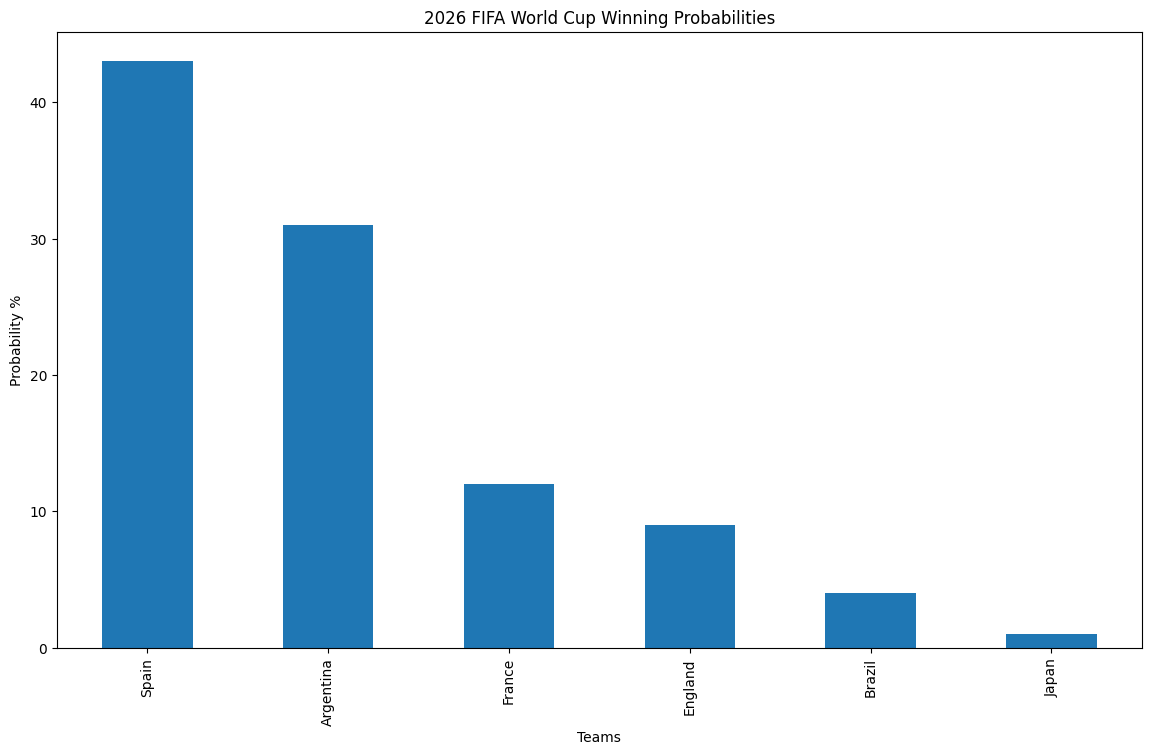

In [83]:
plt.figure(figsize=(14,8))

champion_probs.plot(
    kind='bar'
)

plt.title(
    '2026 FIFA World Cup Winning Probabilities'
)

plt.ylabel('Probability %')

plt.xlabel('Teams')

plt.show()